# Implémentation de la méthode CDF-t

## Importation des bibliothèques

In [7]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from functions import ( 
    csv_to_pd_univ, 
    cdf_t_univ, 
    plot_distributions,
    comparer_distributions,
    extract_month_data,
)

from dOTC import dOTC_df

import numpy as np
import pandas as pd
from scipy import stats

In [4]:
#choix du mois
month = 12

In [5]:
month = 12  # Variable mois définie au début (ex: 12 pour Décembre)
var_name = "tas"

path_CMIP6_hist = "data/CMIP6_historical.csv"
path_CMIP6_fut = "data/CMIP6_ssp585.csv"
path_obs = "data/obs.csv"
path_EUROCORDEX = "data/eurocordex_rcp85.csv"
path_EUROCORDEX_hist = "data/eurocordex_historical.csv"

=== STATISTIQUES DESCRIPTIVES GLOBALES (1995-2014) ===


,Observations,CMIP6 (Hist),EUROCORDEX
count,7305.000000,7305.000000,4018.000000
mean,11.071448,7.959011,7.925921
std,7.359345,7.724778,8.181037
min,-9.275000,-21.072557,-14.922315
5%,-0.612500,-3.696493,-3.587315
25%,5.012500,1.599299,1.787567
50%,11.312500,7.438814,6.428500
75%,17.000000,14.634212,14.591536
95%,22.450000,19.971512,22.026571
max,28.625000,25.351779,26.462765


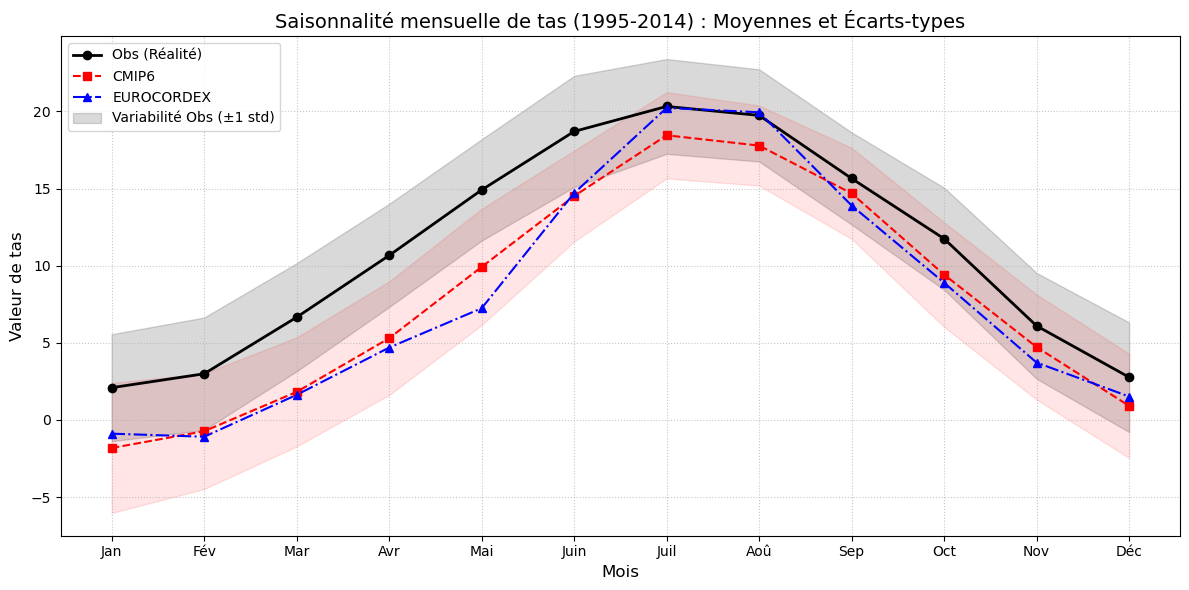

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

years_desc = (1995, 2014)
var_name = "tas"

#  listes pour stocker les données 

stats_mensuelles = []
obs_global = []
cmip6_global = []
euro_global = []

# on prend tous les mois

for m in range(1, 13):
    # extraction
    df_obs = csv_to_pd_univ(path_obs, m, var_name, years=years_desc)
    df_cmip6 = csv_to_pd_univ(path_CMIP6_hist, m, var_name, years=years_desc)
    df_euro = csv_to_pd_univ(path_EUROCORDEX_hist, m, var_name, years=years_desc)
    
    # stockage
    obs_global.append(df_obs)
    cmip6_global.append(df_cmip6)
    euro_global.append(df_euro)
    
    # mesures pour la saisonnalité totale du mois 'm' : moyennes, écart-types
    stats_mensuelles.append({
        'Mois': m,
        'Obs_Moyenne': df_obs[var_name].mean(),
        'Obs_Std': df_obs[var_name].std(),
        'CMIP6_Moyenne': df_cmip6[var_name].mean(),
        'CMIP6_Std': df_cmip6[var_name].std(),
        'Euro_Moyenne': df_euro[var_name].mean(),
        'Euro_Std': df_euro[var_name].std()
    })

#liste into un data frame
df_saisonnalite = pd.DataFrame(stats_mensuelles)

# stats globales sur 20 ANS (tableau classique -  et Quantiles)
df_obs_all = pd.concat(obs_global)
df_cmip6_all = pd.concat(cmip6_global)
df_euro_all = pd.concat(euro_global)

df_comparaison = pd.DataFrame({
    'Observations': df_obs_all[var_name].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]),
    'CMIP6 (Hist)': df_cmip6_all[var_name].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]),
    'EUROCORDEX': df_euro_all[var_name].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
})

print("=== STATISTIQUES DESCRIPTIVES GLOBALES (1995-2014) ===")
display(df_comparaison)

# GRAPHIQUE
plt.figure(figsize=(12, 6))

# Moyennes mensuelles graph 
plt.plot(df_saisonnalite['Mois'], df_saisonnalite['Obs_Moyenne'], label='Obs (Réalité)', color='black', marker='o', linewidth=2)
plt.plot(df_saisonnalite['Mois'], df_saisonnalite['CMIP6_Moyenne'], label='CMIP6', color='red', marker='s', linestyle='--')
plt.plot(df_saisonnalite['Mois'], df_saisonnalite['Euro_Moyenne'], label='EUROCORDEX', color='blue', marker='^', linestyle='-.')

# Variabilité (avec l'écart)type la )
plt.fill_between(df_saisonnalite['Mois'], 
                 df_saisonnalite['Obs_Moyenne'] - df_saisonnalite['Obs_Std'], 
                 df_saisonnalite['Obs_Moyenne'] + df_saisonnalite['Obs_Std'], 
                 color='black', alpha=0.15, label="Variabilité (écart type)")

plt.fill_between(df_saisonnalite['Mois'], 
                 df_saisonnalite['CMIP6_Moyenne'] - df_saisonnalite['CMIP6_Std'], 
                 df_saisonnalite['CMIP6_Moyenne'] + df_saisonnalite['CMIP6_Std'], 
                 color='red', alpha=0.1)

plt.title(f'Saisonnalité mensuelle de {var_name} (1995-2014) : moyennes et écarts-types', fontsize=14)
plt.xlabel('Mois', fontsize=12)
plt.ylabel(f'Valeur de {var_name}', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

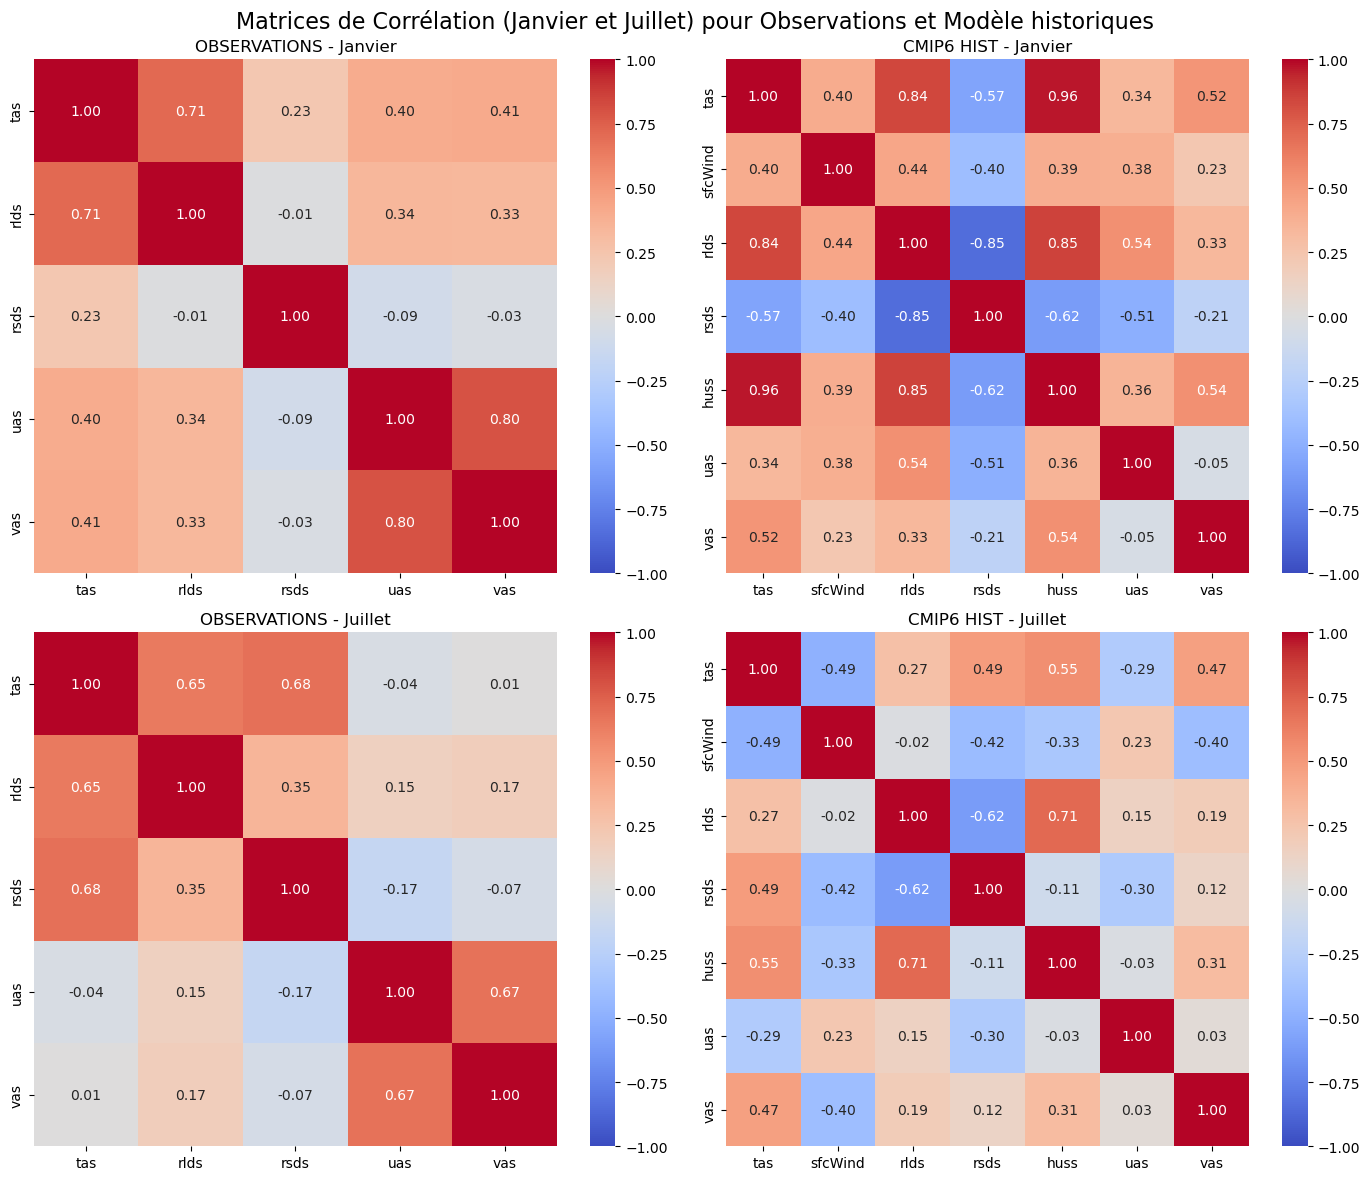

In [7]:
"""On ne concatène pas les mois pour éviter une erreur en mode biais de variable omise dans le sens où ça rajoute de la corrélation de 
mettre tous les mois ensemble car variables ont tendance à toutes changer saisons par saison, 
donc --> forte covariances, due à ce changement structurel métérologique"""
"""----> on isole deux mois Hiver / été pour faire nos matrice de var covar"""

# 1. Variables à étudier
vars_cols_compl = ['tas', 'sfcWind', 'rlds', 'rsds', 'huss', 'uas', 'vas']
vars_cols_sine = ['tas', 'rlds', 'rsds', 'uas', 'vas']

# 2. Chargement des données (L'astuce est ici : on dit à pandas que la colonne 'date' est une vraie date)
# Remplace 'date' par le vrai nom de ta colonne temporelle si besoin (ex: 'time')
df_obs = pd.read_csv(path_obs, sep=';', parse_dates=['date'])
df_cmip6 = pd.read_csv(path_CMIP6_hist, sep=';', parse_dates=['date'])

# --- Filtre optionnel sur la période 1995-2014 ---
df_obs = df_obs[(df_obs['date'].dt.year >= 1995) & (df_obs['date'].dt.year <= 2014)]
df_cmip6 = df_cmip6[(df_cmip6['date'].dt.year >= 1995) & (df_cmip6['date'].dt.year <= 2014)]

# 3. CRÉATION DES FILTRES MENSUELS
# On isole uniquement les données de Janvier (mois 1) et Juillet (mois 7)
df_obs_janv = df_obs[df_obs['date'].dt.month == 1]
df_obs_juil = df_obs[df_obs['date'].dt.month == 7]

df_cmip6_janv = df_cmip6[df_cmip6['date'].dt.month == 1]
df_cmip6_juil = df_cmip6[df_cmip6['date'].dt.month == 7]

# 4. CALCUL DES MATRICES DE CORRÉLATION (sur les mois isolés)
mat_obs_janv = df_obs_janv[vars_cols_sine].corr()
mat_cmip6_janv = df_cmip6_janv[vars_cols_compl].corr()

mat_obs_juil = df_obs_juil[vars_cols_sine].corr()
mat_cmip6_juil = df_cmip6_juil[vars_cols_compl].corr()

# 5. AFFICHAGE GRAPHIQUE COMPARATIF (Hiver vs Été)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Matrices de Corrélation (Janvier et Juillet) pour Observations et Modèle historiques", fontsize=16)

# --- Ligne 1 : JANVIER ---
sns.heatmap(mat_obs_janv, ax=axes[0, 0], annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
axes[0, 0].set_title("OBSERVATIONS - Janvier")

sns.heatmap(mat_cmip6_janv, ax=axes[0, 1], annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
axes[0, 1].set_title("CMIP6 HIST - Janvier")

# --- Ligne 2 : JUILLET ---
sns.heatmap(mat_obs_juil, ax=axes[1, 0], annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
axes[1, 0].set_title("OBSERVATIONS - Juillet")

sns.heatmap(mat_cmip6_juil, ax=axes[1, 1], annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
axes[1, 1].set_title("CMIP6 HIST - Juillet")

plt.tight_layout()
plt.show()

**OBS**

TTEPA
On observe : 

forte correlation positive  entre :
- uas et vas (peu d'intérêt, juste vent fort = augmentation des deux variables donc logique)
- rlds et tas + rsds et tas ==> fortes radiations (<=>ensoleillement) implique plus fortes températures.


==> note : corrélation positive rlds et uas / négative rsds et uas 
: vents polaires trucs de magnétismes là peut-être ? me souviens plus de mes cours de géologie. 
Jsp trop ce qu'on peut en faire.

+ Hiver : température et vent = corrélés positivement.


**Modèle** 

très forte corrélation 
- humidité et température 
- humidité et ondes  

**OBS**

TTEPA
On observe : 

forte correlation positive  entre :
- uas et vas (peu d'intérêt, juste vent fort = augmentation des deux variables donc logique)
- rlds et tas + rsds et tas ==> fortes radiations (<=>ensoleillement) implique plus fortes températures.


==> note : corrélation positive rlds et uas / négative rsds et uas 
: vents polaires trucs de magnétismes là peut-être ? me souviens plus de mes cours de géologie. 
Jsp trop ce qu'on peut en faire.

+ Hiver : température et vent = 

## Implémentation CDF-t univariée (température)

### Correction CMIP6 sur les observations

#### Comparaison valeurs réelles et valeurs corrigées

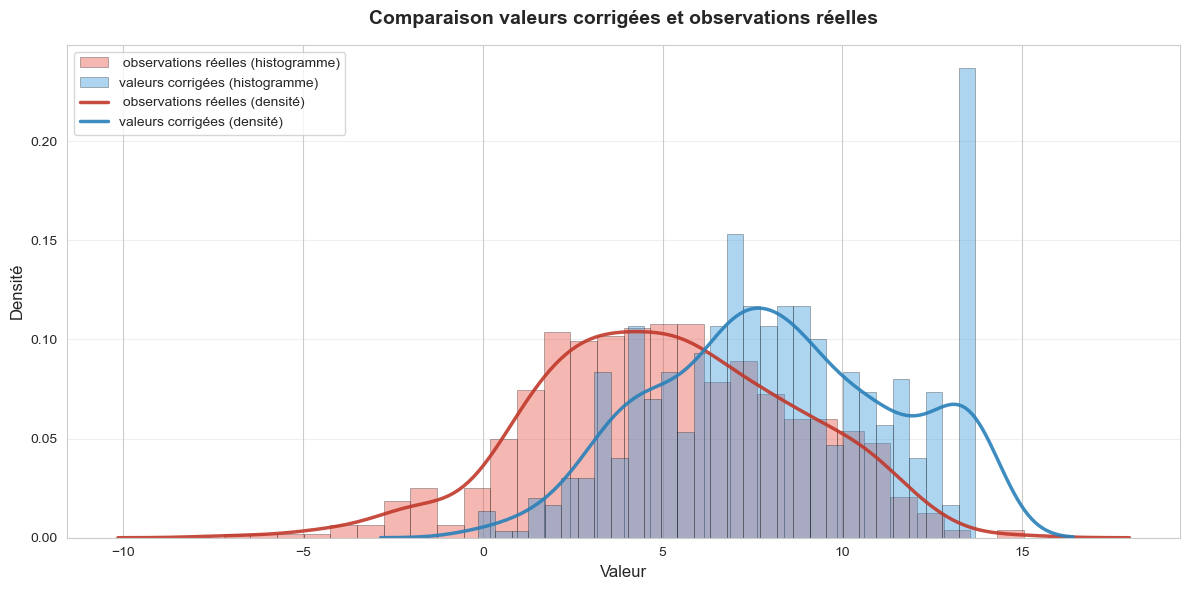

In [6]:
#Sélection mois et variable
CMIP6_hist_complet = pd.read_csv(path_CMIP6_hist)
CMIP6_hist = csv_to_pd_univ(path_CMIP6_hist, month, var_name, years=(1995, 2014))
CMIP6_futur = csv_to_pd_univ(path_CMIP6_fut, month, var_name, years=(2080, 2100))
obs_hist = csv_to_pd_univ(path_obs, month, var_name, years=(1995, 2014))
obs_futur = csv_to_pd_univ(path_EUROCORDEX, month, var_name, years = (2080,2100))
Eurocordex_hist = csv_to_pd_univ(path_EUROCORDEX_hist, month, var_name, years = (1995,2014))


#Correction des valeurs futures du modèle par CDF-t
_, modele_futur_corrige = cdf_t_univ(CMIP6_hist, obs_hist, CMIP6_futur)

#Représentation graphique
plot_distributions((obs_futur, modele_futur_corrige), "Comparaison valeurs corrigées et observations réelles", ("observations réelles","valeurs corrigées"),)

### Comparaison passé/futur dans le modèle et dans les observations (observations futures = valeurs corrigées)

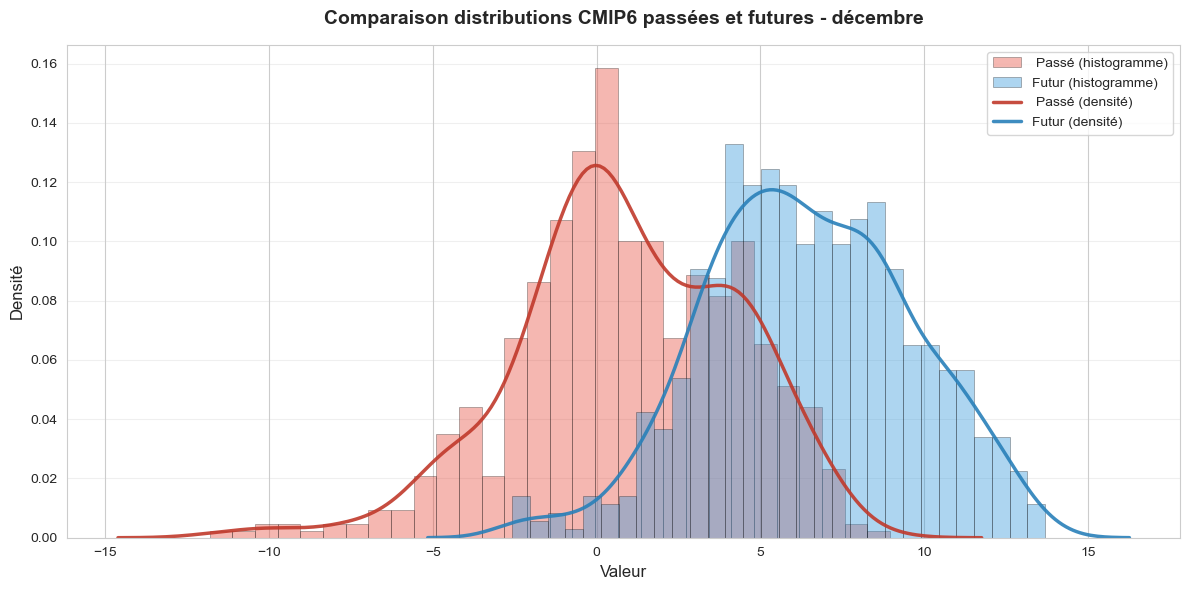

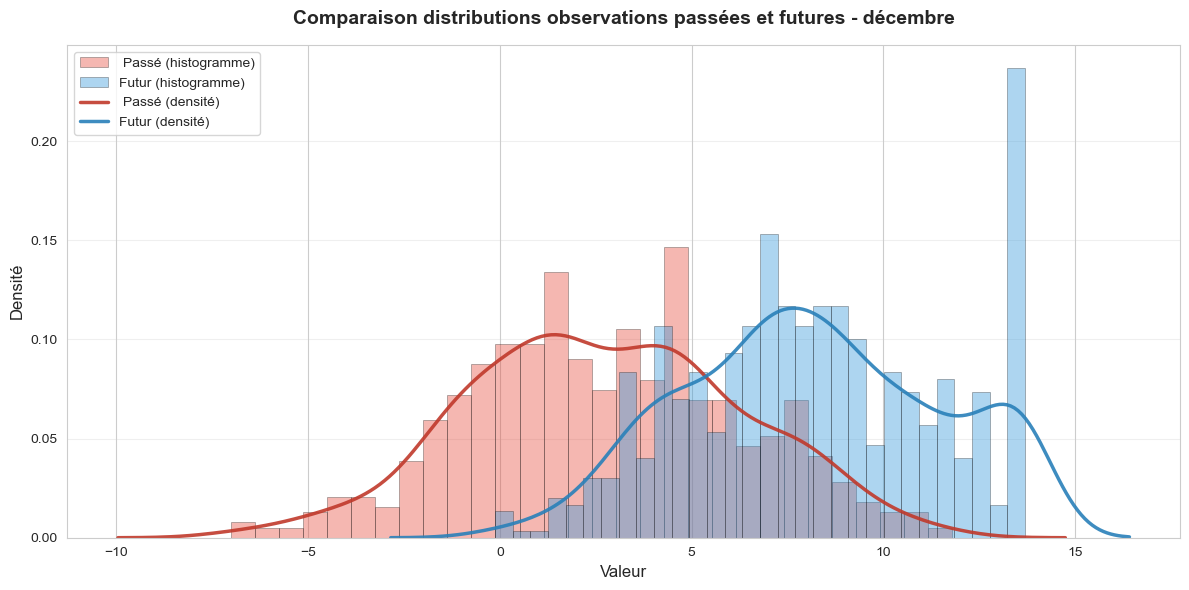

In [3]:
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Représentations graphiques
plot_distributions((CMIP6_hist, CMIP6_futur),"Comparaison distributions CMIP6 passées et futures - décembre",("Passé","Futur"))
plot_distributions((obs_hist,modele_futur_corrige),"Comparaison distributions observations passées et futures - décembre",("Passé","Futur") )

### Comparaison modèle/observations dans le passé et dans le futur (avec valeurs corrigées)

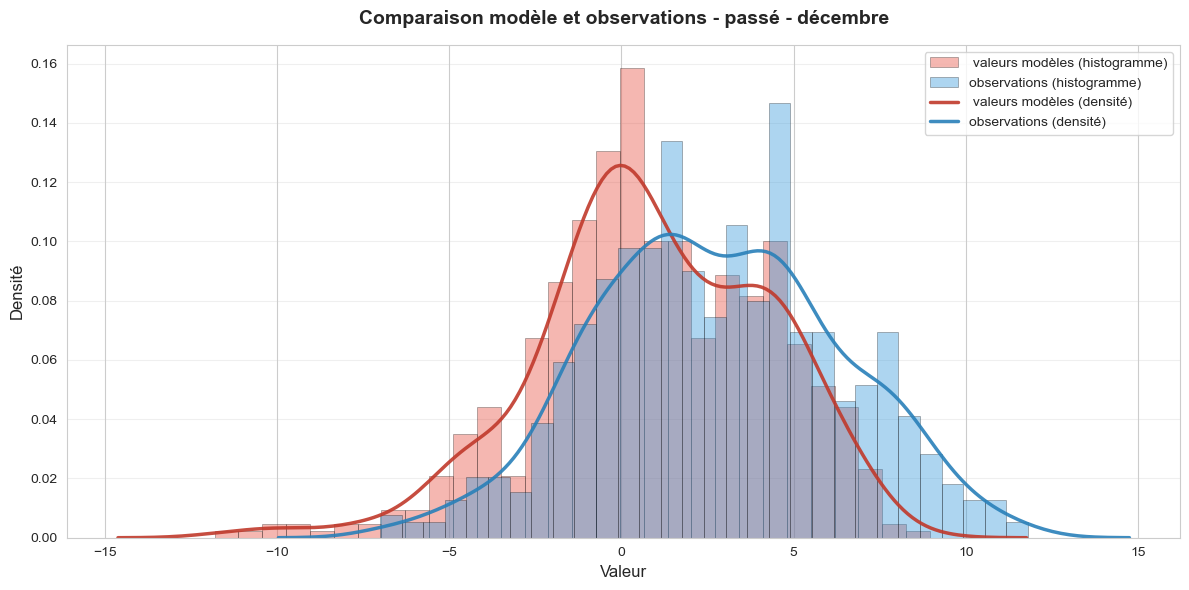

In [ ]:
#Représentation graphique
plot_distributions((CMIP6_hist, obs_hist),
                           "Comparaison modèle et observations - passé - décembre",
                           ("valeurs modèles","observations"))

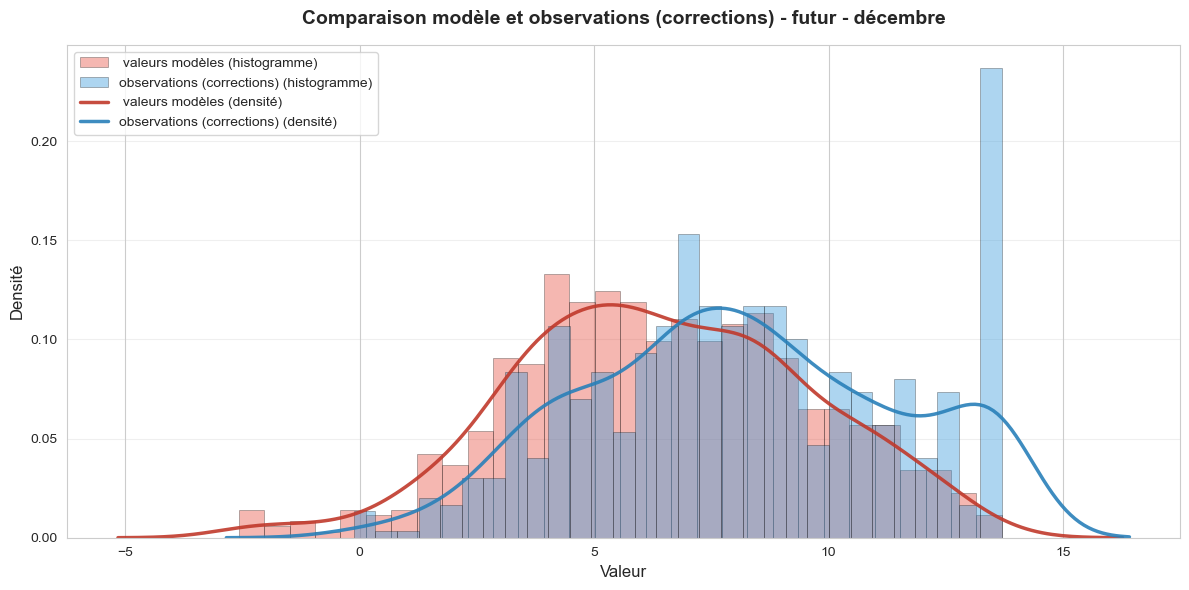

In [ ]:
#Comparaison futur 

#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ(path_CMIP6_hist, 12, "tas", years = (1982,2014))
CMIP6_futur = csv_to_pd_univ(path_CMIP6_fut, 12, "tas", years= (2015,2100))
obs_hist = csv_to_pd_univ(path_obs, 12, "tas", years = (1982,2014))

#Correction des valeurs futures du modèle par CDF-t
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Représentation graphique
plot_distributions((CMIP6_futur, modele_futur_corrige),
                           "Comparaison modèle et observations (corrections) - futur - décembre",
                           ("valeurs modèles","observations (corrections)"))

Test avec EUROCORDEX pour vérifier

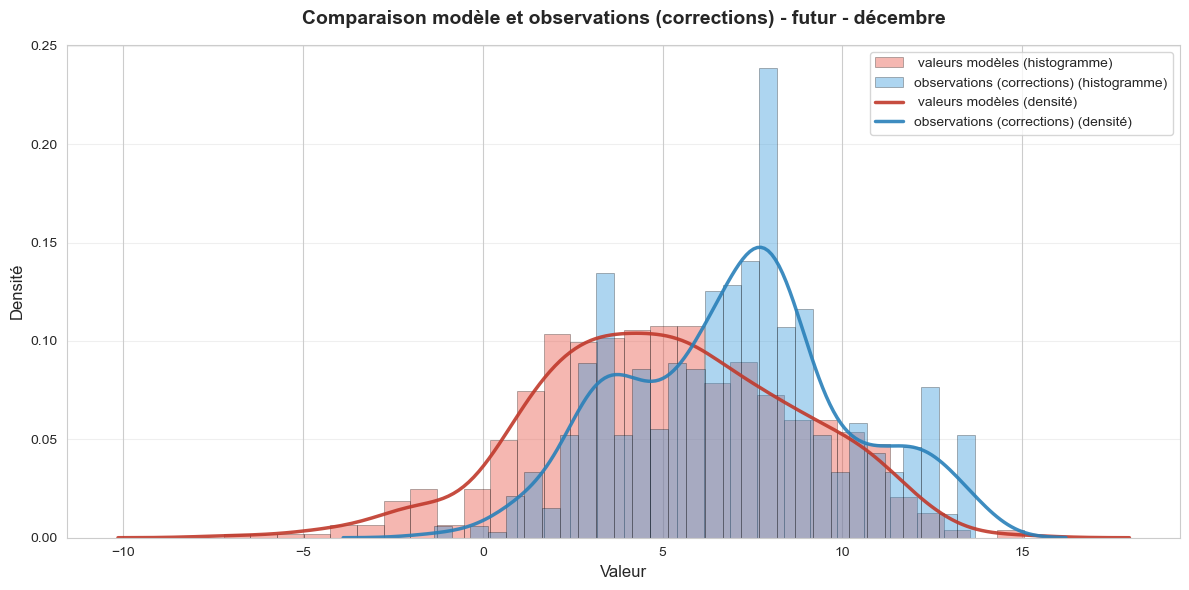

"\nplot_cdf_t(\n    EUROCORDEX_mois_tas,  # brut\n    mod_hist_corr,         # CMIP5 historique corrigé\n    obs_mois[1]['tas'],    # observations\n    fut_corr               # CMIP5 futur corrigé\n)\n"

In [12]:
_ ,test_futur_corrige  = cdf_t_univ(CMIP6_hist,Eurocordex_hist,CMIP6_futur) 

plot_distributions((obs_futur, test_futur_corrige),
                           "Comparaison modèle et observations (corrections) - futur - décembre",
                           ("valeurs modèles","observations (corrections)"))

"""
plot_cdf_t(
    EUROCORDEX_mois_tas,  # brut
    mod_hist_corr,         # CMIP5 historique corrigé
    obs_mois[1]['tas'],    # observations
    fut_corr               # CMIP5 futur corrigé
)
"""

### Cas gaussien

Paramètres estimés (MLE) :
CMIP6_hist : μ=0.55, σ=3.67
CMIP6_futur : μ=3.48, σ=4.36
obs_hist : μ=2.86, σ=3.88

Paramètres de la loi X :
μ_X = 6.22
σ_X = 4.61


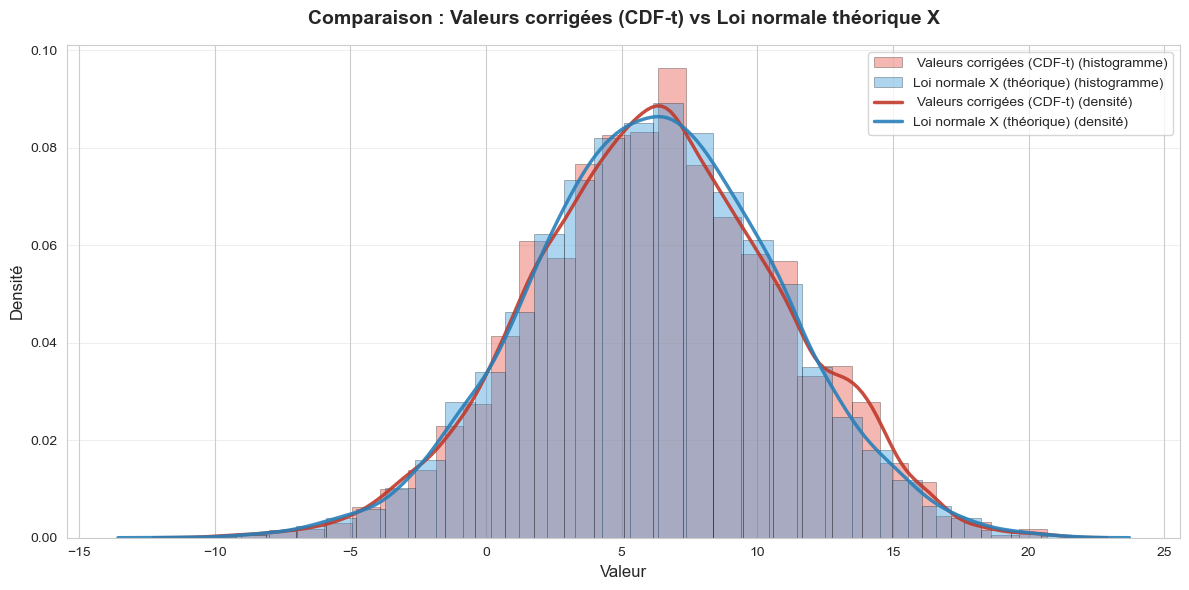

In [7]:
#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ("data/CMIP6_historical.csv", month, "tas", years = (1995,2014))
CMIP6_futur = csv_to_pd_univ("data/CMIP6_ssp585.csv", month, "tas", years= (2080,2100))
obs_hist = csv_to_pd_univ("data/obs.csv", month, "tas" , years = (1995,2014))


# ============================================================================
# ÉTAPE 1 : Estimer les paramètres des lois gaussiennes
# ============================================================================

# Extraire les données (supposant une seule colonne par DataFrame)
data_CMIP6_hist = CMIP6_hist.iloc[:, 0]
data_CMIP6_futur = CMIP6_futur.iloc[:, 0]
data_obs_hist = obs_hist.iloc[:, 0]

# Estimer les paramètres avec Maximum de Vraisemblance (MLE)
mu_CMIP6_hist, sigma_CMIP6_hist = stats.norm.fit(data_CMIP6_hist)
mu_CMIP6_futur, sigma_CMIP6_futur = stats.norm.fit(data_CMIP6_futur)
mu_obs_hist, sigma_obs_hist = stats.norm.fit(data_obs_hist)

print("Paramètres estimés (MLE) :")
print(f"CMIP6_hist : μ={mu_CMIP6_hist:.2f}, σ={sigma_CMIP6_hist:.2f}")
print(f"CMIP6_futur : μ={mu_CMIP6_futur:.2f}, σ={sigma_CMIP6_futur:.2f}")
print(f"obs_hist : μ={mu_obs_hist:.2f}, σ={sigma_obs_hist:.2f}")

# ============================================================================
# ÉTAPE 2 : Simuler 10000 valeurs pour chaque variable aléatoire
# ============================================================================

n_simulations = 10000

# Simuler depuis les lois gaussiennes estimées
sim_CMIP6_hist = np.random.normal(mu_CMIP6_hist, sigma_CMIP6_hist, n_simulations)
sim_CMIP6_futur = np.random.normal(mu_CMIP6_futur, sigma_CMIP6_futur, n_simulations)
sim_obs_hist = np.random.normal(mu_obs_hist, sigma_obs_hist, n_simulations)

# Créer les DataFrames
CMIP6_hist_norm = pd.DataFrame({'CMIP6_hist_sim': sim_CMIP6_hist})
CMIP6_futur_norm = pd.DataFrame({'CMIP6_futur_sim': sim_CMIP6_futur})
obs_hist_norm = pd.DataFrame({'obs_hist_sim': sim_obs_hist})

# ============================================================================
# ÉTAPE 3 : Appliquer la fonction cdf_t_univ
# ============================================================================

df_futur_sim, df_corrige = cdf_t_univ(CMIP6_hist_norm, obs_hist_norm, CMIP6_futur_norm)

# ============================================================================
# ÉTAPE 4 : Simuler la loi normale X avec les paramètres calculés
# ============================================================================

# Calculer les paramètres de X directement avec les paramètres estimés
mu_X = mu_CMIP6_futur + (mu_obs_hist - mu_CMIP6_hist) * (sigma_CMIP6_futur / sigma_CMIP6_hist)
sigma_X = sigma_obs_hist * (sigma_CMIP6_futur / sigma_CMIP6_hist)

print("\nParamètres de la loi X :")
print(f"μ_X = {mu_X:.2f}")
print(f"σ_X = {sigma_X:.2f}")

# Simuler X
sim_X = np.random.normal(mu_X, sigma_X, n_simulations)
df_X = pd.DataFrame({'X_theorique': sim_X})

# ============================================================================
# ÉTAPE 5 : Comparer les distributions avec plot_distributions
# ============================================================================

# Créer le tuple des DataFrames
dfs_tuple = (df_corrige, df_X)

# Créer le titre
titre = "Comparaison : Valeurs corrigées (CDF-t) vs Loi normale théorique X"

# Créer les labels
labels_tuple = ("Valeurs corrigées (CDF-t)", "Loi normale X (théorique)")

# Tracer les distributions
plot_distributions(dfs_tuple, titre, labels_tuple)



### Validation croisée avec CMIP6 et observations

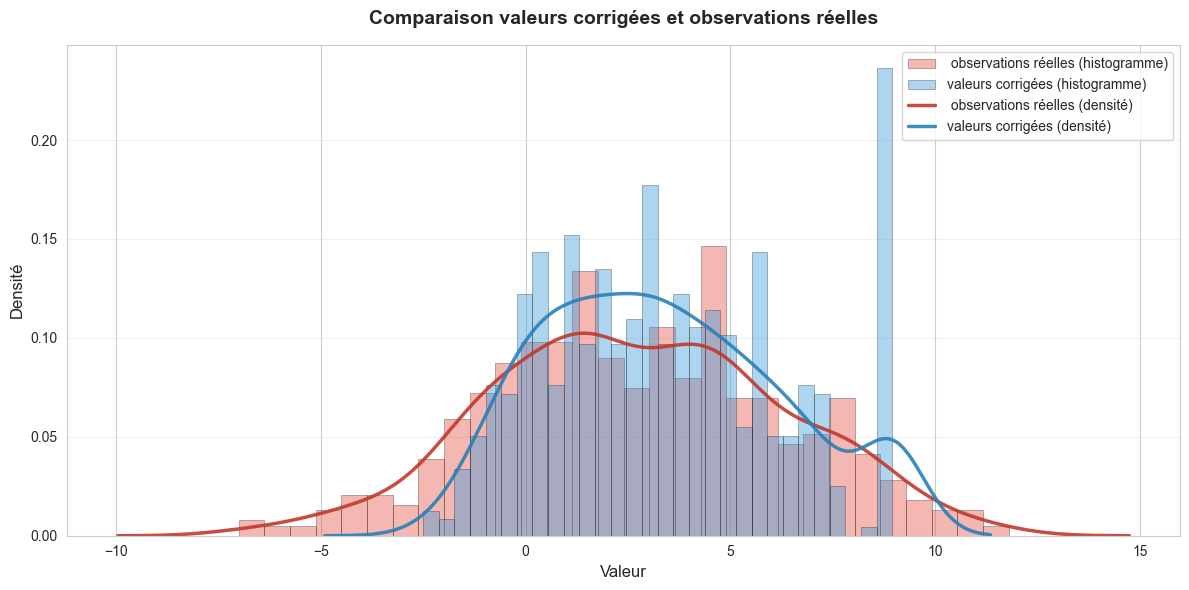

           Distribution  Espérance   Variance
0  Observations réelles   2.767601  12.631704
1     Valeurs corrigées   3.380726   8.362937
   Différence des espérances  Rapport des variances  KS statistique  \
0                   0.613125               0.662059        0.120968   

   KS p-value  
0    0.000226  


In [4]:
#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ(r"data/CMIP6_historical.csv", month, "tas", years = (1975,1994))
CMIP6_futur = csv_to_pd_univ(r"data/CMIP6_historical.csv", month, "tas", years= (1995,2014))
obs_hist = csv_to_pd_univ(r"data/obs.csv", month, "tas", years = (1975,1994))
obs_futur = csv_to_pd_univ(r"data/obs.csv", month, "tas", years = (1995,2014))

#Correction des valeurs futures du modèle par CDF-t
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Comparaison graphique et statistique
plot_distributions((obs_futur, modele_futur_corrige),
                    "Comparaison valeurs corrigées et observations réelles",
                    ("observations réelles","valeurs corrigées"),)
stat, summary = comparer_distributions(obs_futur,"Observations réelles",modele_futur_corrige,"Valeurs corrigées")
print(stat)
print(summary)

In [5]:
#Comparaison modèle non corrigé et observations réelles sur 1995-2014
stat, summary = comparer_distributions(obs_futur,"Observations réelles",CMIP6_futur,"Modèle non corrigé")
print(stat)
print(summary)

           Distribution  Espérance   Variance
0  Observations réelles   2.767601  12.631704
1    Modèle non corrigé   0.910318  11.428635
   Différence des espérances  Rapport des variances  KS statistique  \
0                  -1.857283               0.904758        0.214516   

     KS p-value  
0  6.663891e-13  


### Validation croisée avec CMIP5 et Eurocordex

In [ ]:
#Sélection mois et variable
CMIP5_hist = csv_to_pd_univ(r"data/CMIP5_historical.csv", month, "tas", years = (1996,2005))
CMIP5_futur = csv_to_pd_univ(r"data/CMIP5_rcp85.csv", month, "tas", years= (2081,2100))
obs_hist = csv_to_pd_univ(r"data/eurocordex_historical.csv", month, "tas", years = (1996,2005))
obs_futur = csv_to_pd_univ(r"data/eurocordex_rcp85.csv", month, "tas", years = (2081,2100))

#Correction des valeurs futures du modèle par CDF-t
_ ,modele_futur_corrige  = cdf_t_univ(CMIP5_hist,obs_hist,CMIP5_futur) 

#Représentation graphique
plot_distributions((obs_futur, modele_futur_corrige),
                    "Comparaison valeurs corrigées et observations réelles",
                    ("observations réelles","valeurs corrigées"),)
stat, summary = comparer_distributions(obs_futur,"Observations réelles",modele_futur_corrige,"Valeurs corrigées")
print(stat)
print(summary)

In [ ]:
#Comparaison modèle non corrigé et observations réelles sur 2081-2100
stat, summary = comparer_distributions(obs_futur,"Observations réelles",CMIP5_futur,"Modèle non corrigé")
print(stat)
print(summary)

## Correction multivariée

### Validation croisée avec CMIP6 et observations

In [6]:
colonnes_communes = ["tas", "rlds", "rsds", "uas", "vas"]
colonnes_choisies = ["tas","rlds","rsds","uas","vas"]

CMIP6_hist = extract_month_data(r"data/CMIP6_historical.csv", month, colonnes_choisies, (1975,1994))
CMIP6_futur = extract_month_data(r"data/CMIP6_historical.csv", month, colonnes_choisies, (1995,2014))
obs_hist = extract_month_data(r"data/obs.csv", month, colonnes_choisies, (1975,1994))
obs_futur = extract_month_data(r"data/obs.csv", month, colonnes_choisies, (1995,2014))

In [7]:
#Correction des valeurs futures du modèle par CDF-t
obs_cor_cdft = cdf_t_multiv(CMIP6_hist, obs_hist, CMIP6_futur)

#Correction par transport optimal
_, obs_cor_ot = dOTC_df(CMIP6_hist, CMIP6_futur, obs_hist)

In [9]:
#Corrélation de Spearman et copules empiriques

variables = ['rlds', 'rsds']

#Correction par CDF-t variable par variable
print("Correction par CDF-t variable par variable")
rho1, rho2, diff = compare_spearman(obs_cor_cdft, obs_futur, variables)
print(f"Rho de Spearman (obs_cor_cdft) : {rho1:.4f}")
print(f"Rho de Spearman (obs_futur) : {rho2:.4f}")
print(f"Différence : {diff:.4f}")

#compare_joint_distributions(obs_cor_cdft, obs_futur, variables) 

#Correction par transport optimal
print("Correction par transport optimal")
rho1, rho2, diff = compare_spearman(obs_cor_ot, obs_futur, variables)
print(f"Rho de Spearman (obs_cor_ot) : {rho1:.4f}")
print(f"Rho de Spearman (obs_futur) : {rho2:.4f}")
print(f"Différence : {diff:.4f}")

#Non-correction du modèle
print("Non-correction du modèle")
rho1, rho2, diff = compare_spearman(CMIP6_futur, obs_futur, variables)
print(f"Rho de Spearman (CMIP6_futur) : {rho1:.4f}")
print(f"Rho de Spearman (obs_futur) : {rho2:.4f}")
print(f"Différence : {diff:.4f}")

#compare_joint_distributions(obs_cor_ot, obs_futur, variables)

Correction par CDF-t variable par variable
Rho de Spearman (obs_cor_cdft) : -0.7697
Rho de Spearman (obs_futur) : -0.6061
Différence : -0.1636
Correction par transport optimal
Rho de Spearman (obs_cor_ot) : -0.5301
Rho de Spearman (obs_futur) : -0.6061
Différence : 0.0760
Non-correction du modèle
Rho de Spearman (CMIP6_futur) : -0.7699
Rho de Spearman (obs_futur) : -0.6061
Différence : -0.1638


### Cas gaussien

Rho de Spearman (Y1_gaussian) : -0.6922
Rho de Spearman (Y1_dOTC) : -0.6521
Différence : -0.0400


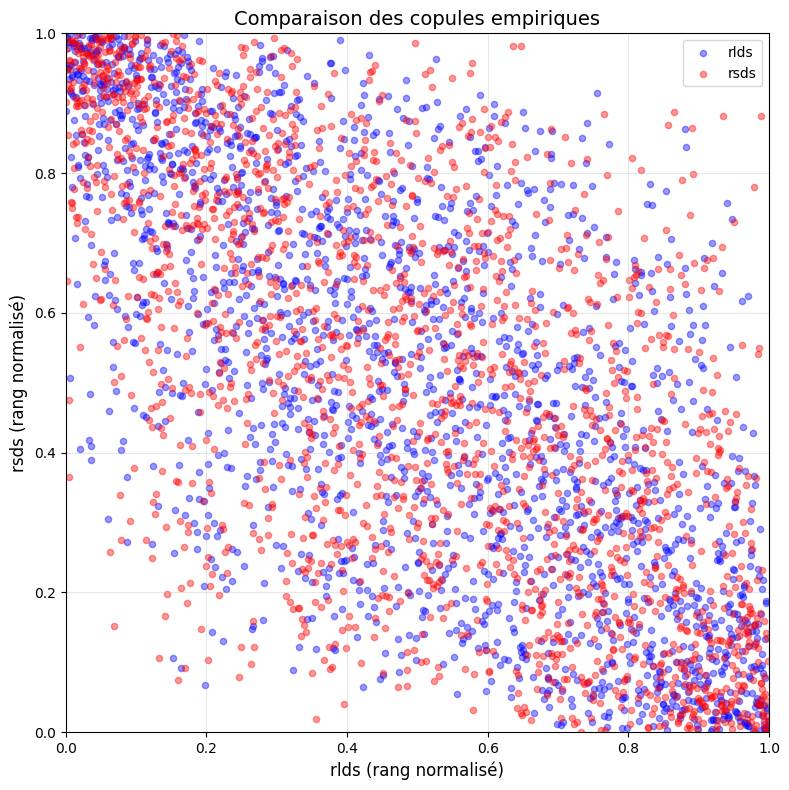

In [ ]:
#Charger les données multivariées
colonnes_communes = ["tas", "rlds", "rsds", "uas", "vas"]
colonnes_choisies = ["tas","rlds","rsds","uas","vas"]

CMIP6_hist  = extract_month_data("data/CMIP6_historical.csv", month, colonnes_choisies, (1975, 1994))
CMIP6_futur = extract_month_data("data/CMIP6_ssp585.csv",     month, colonnes_choisies, (2080, 2100))
obs_hist    = extract_month_data("data/obs.csv",               month, colonnes_choisies, (1975, 1994))

#Estimer les paramètres des lois normales multivariées (MLE)

mu_CMIP6_hist  = CMIP6_hist.mean(axis=0).values
mu_CMIP6_futur = CMIP6_futur.mean(axis=0).values
mu_obs_hist    = obs_hist.mean(axis=0).values

Sigma_CMIP6_hist  = np.cov(CMIP6_hist.values.T)
Sigma_CMIP6_futur = np.cov(CMIP6_futur.values.T)
Sigma_obs_hist    = np.cov(obs_hist.values.T)

#Simuler 2000 réalisations depuis chaque loi normale multivariée

n_simulations = 2000

sim_CMIP6_hist  = np.random.multivariate_normal(mu_CMIP6_hist,  Sigma_CMIP6_hist,  n_simulations)
sim_CMIP6_futur = np.random.multivariate_normal(mu_CMIP6_futur, Sigma_CMIP6_futur, n_simulations)
sim_obs_hist    = np.random.multivariate_normal(mu_obs_hist,    Sigma_obs_hist,    n_simulations)

CMIP6_hist_sim  = pd.DataFrame(sim_CMIP6_hist,  columns=colonnes_choisies)
CMIP6_futur_sim = pd.DataFrame(sim_CMIP6_futur, columns=colonnes_choisies)
obs_hist_sim    = pd.DataFrame(sim_obs_hist,     columns=colonnes_choisies)

#Construire Y1 de deux manières à partir des simulations

# --- Méthode 1 : gaussian_ot (Bures-Wasserstein, forme close) ---
# Apprend le transport linéaire X0->X1 (évolution du modèle)
# et l'applique à Y0 (observations) pour produire Y1
# Ordre des paramètres : (modele_hist, obs_hist, modele_futur)
Y1_gaussian = gaussian_ot(CMIP6_hist_sim, obs_hist_sim, CMIP6_futur_sim)

# --- Méthode 2 : dOTC_df (transport optimal dynamique, non-paramétrique) ---
# Même logique conceptuelle mais sans hypothèse gaussienne
# Ordre des paramètres : (X0, X1, Y0)
_, Y1_dOTC = dOTC_df(CMIP6_hist_sim, CMIP6_futur_sim, obs_hist_sim)

#Comparaison Y1_gaussian et Y1_dOTC : corrélation de Spearman et copules empiriques

variables = ['rlds', 'rsds']

rho1, rho2, diff = compare_spearman(Y1_gaussian, Y1_dOTC, variables)
print(f"Rho de Spearman (Y1_gaussian) : {rho1:.4f}")
print(f"Rho de Spearman (Y1_dOTC) : {rho2:.4f}")
print(f"Différence : {diff:.4f}")

compare_joint_distributions(Y1_gaussian, Y1_dOTC, variables)